In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error


In [22]:
dfTrain = pd.read_csv('train.csv') # /kaggle/input/playground-series-s5e4/
dfTest  = pd.read_csv('test.csv')
submission = pd.read_csv('sample_submission.csv')

In [23]:
dfTrain.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031


In [24]:
# Check number of rows and columns
print(f"Train shape: {dfTrain.shape}")

Train shape: (750000, 12)


# Exploration and Cleaning
With the data imported, we can take a look at each column. From the quick view above, it's possible to see that there's a residual `id` column and NaN values.

In [25]:
# Let's check for Missing Values, Duplicates, and Data Types
# Remove unnecessary columns
dfTrain.drop(columns=['id'], inplace=True)
dfTest.drop(columns=['id'], inplace=True)


print("Null:\n", dfTrain.isnull().sum())
print("\nDuplicate:\n",dfTrain.duplicated().sum())
print("\nType:\n",dfTrain.dtypes)

Null:
 Podcast_Name                        0
Episode_Title                       0
Episode_Length_minutes          87093
Genre                               0
Host_Popularity_percentage          0
Publication_Day                     0
Publication_Time                    0
Guest_Popularity_percentage    146030
Number_of_Ads                       1
Episode_Sentiment                   0
Listening_Time_minutes              0
dtype: int64

Duplicate:
 0

Type:
 Podcast_Name                    object
Episode_Title                   object
Episode_Length_minutes         float64
Genre                           object
Host_Popularity_percentage     float64
Publication_Day                 object
Publication_Time                object
Guest_Popularity_percentage    float64
Number_of_Ads                  float64
Episode_Sentiment               object
Listening_Time_minutes         float64
dtype: object


From this initial exploration, it can be seen that there are many missing values in `Episode_Length_minutes` and `Guest_Popularity_percentage` and 1 missing value in `Number_of_Ads`. It will be interesting to see whether the missing values in `Guest_Popularity_percentage` could be attributed to a lack of guest, and we could treat this variable in another way that accounts for that if it is the case. It is also interesting to note that, while `Episode_Length_minutes` has missing values, `Listening_Time_minutes`, the outcome, does not, so we can have an idea of the minimun length of the episode.

In [26]:
# Let's see example of rows with missing values
display(dfTrain[dfTrain.isnull().any(axis=1)].head(10))

,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
5,Fitness First,Episode 19,26.54,Health,48.96,Saturday,Afternoon,NaN,3.0,Positive,22.77047
8,Daily Digest,Episode 32,105.87,News,69.81,Monday,Evening,NaN,2.0,Neutral,68.00124
9,Music Matters,Episode 81,NaN,Music,82.18,Thursday,Night,59.72,3.0,Neutral,45.94761
16,Study Sessions,Episode 82,78.47,Education,48.84,Sunday,Afternoon,NaN,2.0,Neutral,42.89441
20,Funny Folks,Episode 100,54.67,Comedy,45.47,Wednesday,Afternoon,NaN,2.0,Neutral,29.22750
21,Sports Weekly,Episode 100,67.05,Sports,58.77,Saturday,Night,NaN,0.0,Neutral,56.87222
26,Sports Weekly,Episode 27,110.70,Sports,98.58,Saturday,Night,NaN,2.0,Positive,93.02372
29,Health Hour,Episode 38,NaN,Health,45.97,Saturday,Evening,15.43,1.0,Negative,25.38384
32,Sound Waves,Episode 74,117.88,Music,41.28,Saturday,Morning,NaN,0.0,Positive,101.19214


In [27]:
# Let's now see which Podcasts have more than 1 missing values and whether there are any without a single missing value, then we can group by the Podcast_Name and see how many missing values each Podcast has

missing_values = dfTrain[dfTrain.isnull().any(axis=1)].groupby('Podcast_Name').size().reset_index(name='Missing_Values')


# Check if any Podcast_Name has no missing values
print(f"Podcast_Name with no missing values: {missing_values[missing_values['Missing_Values'] == 0].shape[0]}")

# Average number of missing values per Podcast_Name
print(f"Average number of missing values per Podcast_Name: {missing_values['Missing_Values'].mean()}")



Podcast_Name with no missing values: 0
Average number of missing values per Podcast_Name: 4394.833333333333


Text(0.5, 1.0, 'Distribution of Listening Time (minutes)')

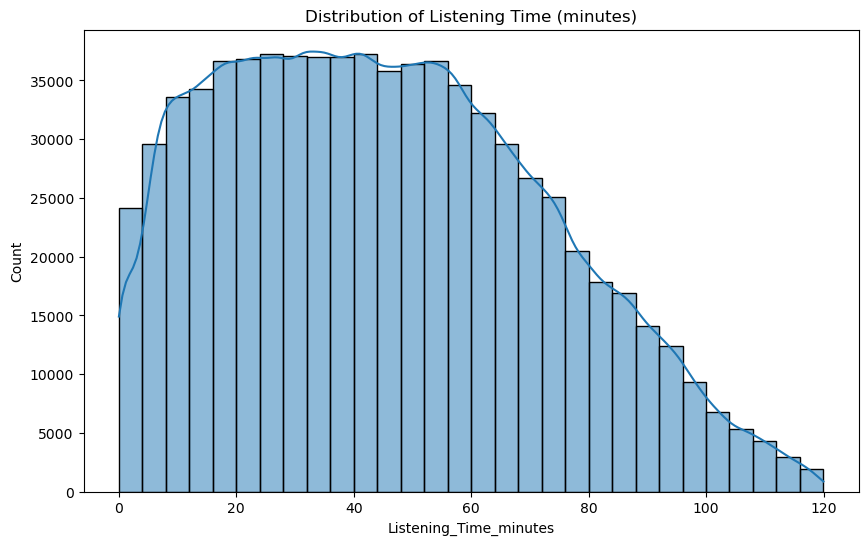

In [28]:
# Let's do some graphs to better understand the data

# Let's see the distribution of the target variable Listening_Time_minutes
plt.figure(figsize=(10, 6))
sns.histplot(dfTrain['Listening_Time_minutes'], bins=30, kde=True)
plt.title('Distribution of Listening Time (minutes)')



Text(0.5, 1.0, 'Total number of episodes (rows) per Podcast_Name')

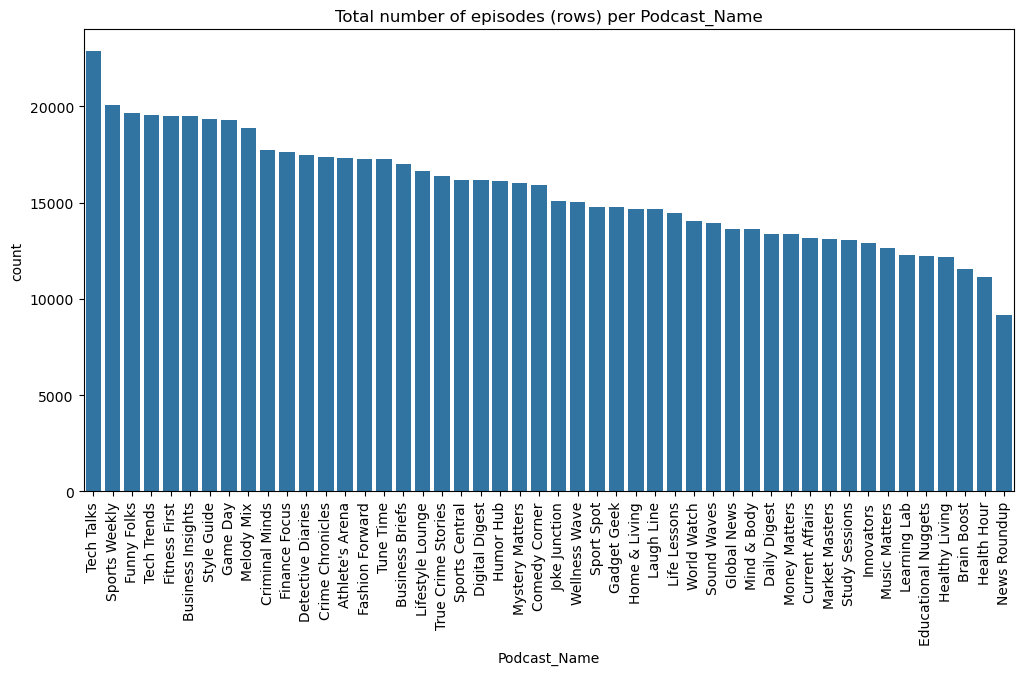

In [29]:
# Total number of episodes (rows) per Podcast_Name
plt.figure(figsize=(12, 6))

sns.countplot(data=dfTrain, x='Podcast_Name', order=dfTrain['Podcast_Name'].value_counts().index)
plt.xticks(rotation=90)
plt.title('Total number of episodes (rows) per Podcast_Name')


(-1.099999985701305, 1.099999985658281, -1.099999878092411, 1.099999977150123)

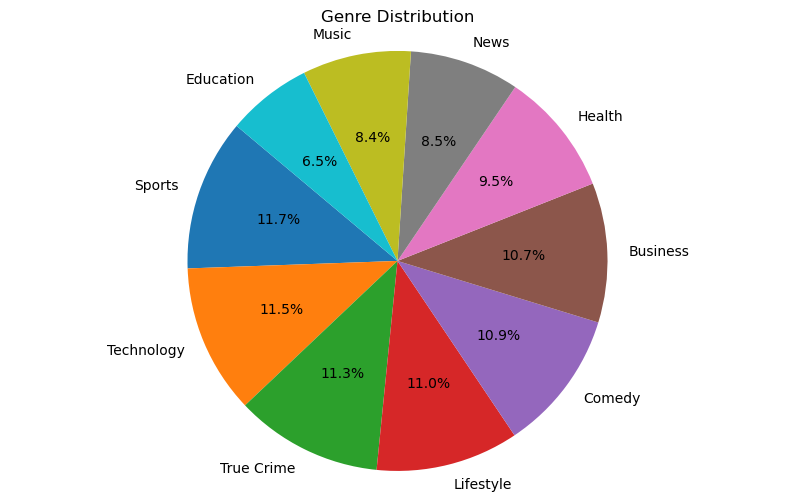

In [30]:
# Pie chart of Genre distribution
genre_counts = dfTrain['Genre'].value_counts()

plt.figure(figsize=(10, 6))
plt.pie(genre_counts, labels=genre_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Genre Distribution')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.


The distributions for most genres are quite close, although education is significantly lower than the others.

Text(0.5, 1.0, 'Distribution of Episode Length (minutes)')

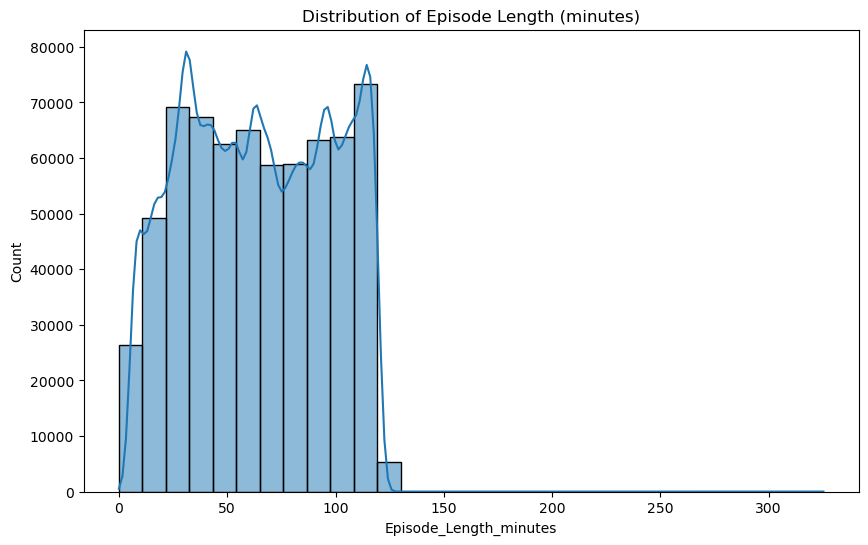

In [31]:
# Distribution of Episode length in minutes
plt.figure(figsize=(10, 6))
sns.histplot(dfTrain['Episode_Length_minutes'], bins=30, kde=True)
plt.title('Distribution of Episode Length (minutes)')

(-1.0999983626808423,
 1.0999994706721943,
 -1.0999996819122309,
 1.0999999247523142)

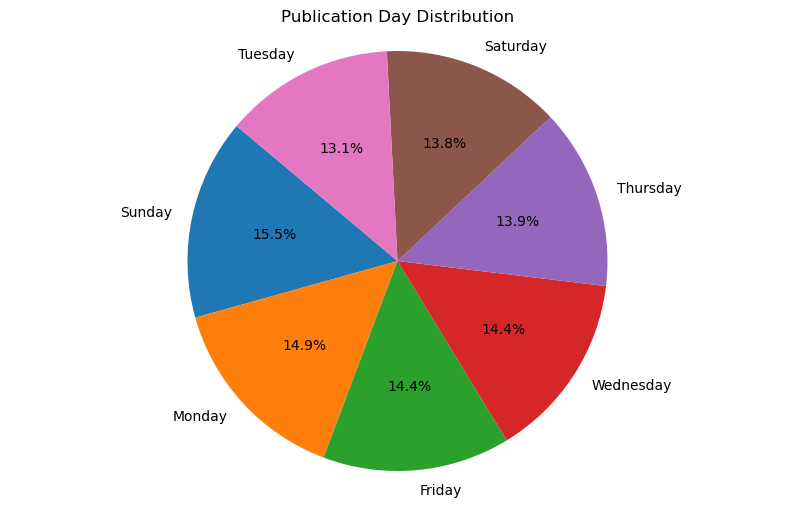

In [32]:
# Pie chart for Publication_Day and Publication_Time

publication_day_counts = dfTrain['Publication_Day'].value_counts()

plt.figure(figsize=(10, 6))
plt.pie(publication_day_counts, labels=publication_day_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Publication Day Distribution')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

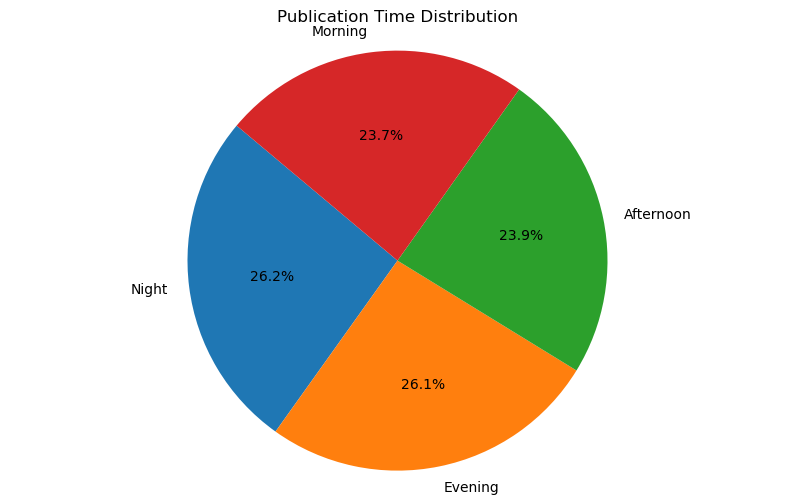

In [33]:
def pie_chart_maker(df, column_name, title):
    counts = df[column_name].value_counts()
    plt.figure(figsize=(10, 6))
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140)
    plt.title(title)
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.show()

pie_chart_maker(dfTrain, 'Publication_Time', 'Publication Time Distribution')

Text(0.5, 1.0, 'Distribution of Number of Ads')

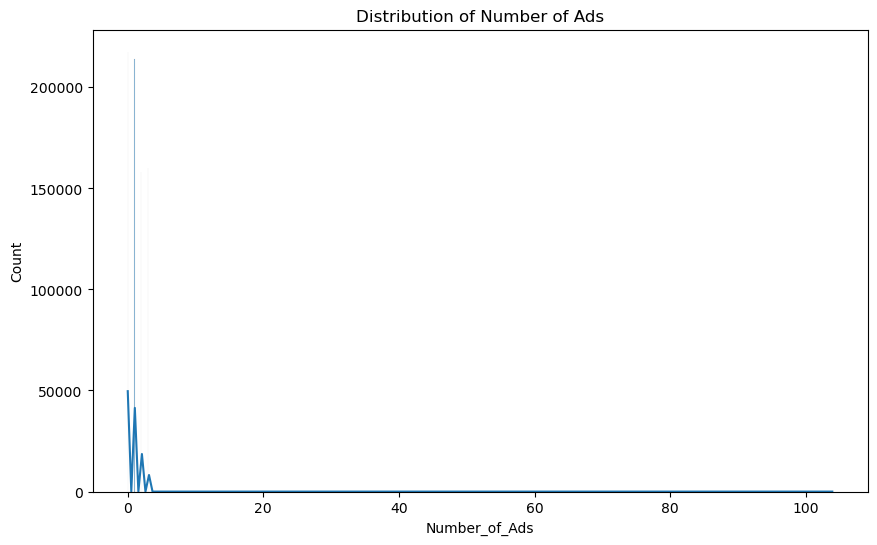

In [34]:
# Number_of_Ads distribution
plt.figure(figsize=(10, 6))
sns.histplot(dfTrain['Number_of_Ads'], kde=True)
plt.title('Distribution of Number of Ads')


In [35]:
# Check if the values in Host_Popularity_percentage and Guest_Popularity_percentage are between 0 and 100, accounting for missing values in the later

print("Host_Popularity_percentage:")
print(f"Min: {dfTrain['Host_Popularity_percentage'].min()}")
print(f"Max: {dfTrain['Host_Popularity_percentage'].max()}")

print("\nGuest_Popularity_percentage:")
print(f"Min: {dfTrain['Guest_Popularity_percentage'].min()}")
print(f"Max: {dfTrain['Guest_Popularity_percentage'].max()}")




Host_Popularity_percentage:
Min: 1.3
Max: 119.46

Guest_Popularity_percentage:
Min: 0.0
Max: 119.91


So there are Guests and Hosts with over 100 popularity percentage, which is impossible in practice.

In [36]:
# See which rows have a value above 100 for Host_Popularity_percentage and Guest_Popularity_percentage
irregularities = dfTrain[(dfTrain['Host_Popularity_percentage'] > 100) | (dfTrain['Guest_Popularity_percentage'] > 100)]
print(f"\nNumber of irregularities: {irregularities.shape[0]}")
irregularities



Number of irregularities: 44


,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
6770,Tune Time,Episode 85,NaN,Music,73.54,Wednesday,Night,107.08,0.0,Positive,35.25323
23925,Fitness First,Episode 79,93.17,Health,117.76,Sunday,Morning,67.73,2.0,Positive,81.23646
32435,World Watch,Episode 44,10.94,News,35.98,Thursday,Afternoon,114.72,0.0,Negative,1.62509
79078,Current Affairs,Episode 17,107.24,News,118.73,Sunday,Evening,71.24,1.0,Positive,50.49238
86967,Tune Time,Episode 68,35.62,Music,27.20,Monday,Night,106.90,0.0,Positive,32.97339
106804,Tune Time,Episode 79,45.36,Music,58.79,Monday,Evening,110.14,2.0,Negative,31.53171
111850,Melody Mix,Episode 43,115.31,Music,105.57,Wednesday,Morning,52.25,0.0,Neutral,103.93098
113304,Wellness Wave,Episode 67,35.35,Health,115.18,Sunday,Morning,1.63,0.0,Negative,30.61016
118315,Style Guide,Episode 32,80.30,Lifestyle,29.95,Wednesday,Afternoon,102.13,1.0,Negative,54.73758
123611,Finance Focus,Episode 86,34.18,Business,112.25,Wednesday,Morning,85.48,1.0,Positive,21.66793


It seems that `Number_of_Ads` has some outliers we might have to deal with.

In [37]:
# Check for rows that have more than 3 ads
print(f"Number of rows with more than 3 ads: {dfTrain[dfTrain['Number_of_Ads'] > 3].shape[0]}")

Number of rows with more than 3 ads: 9


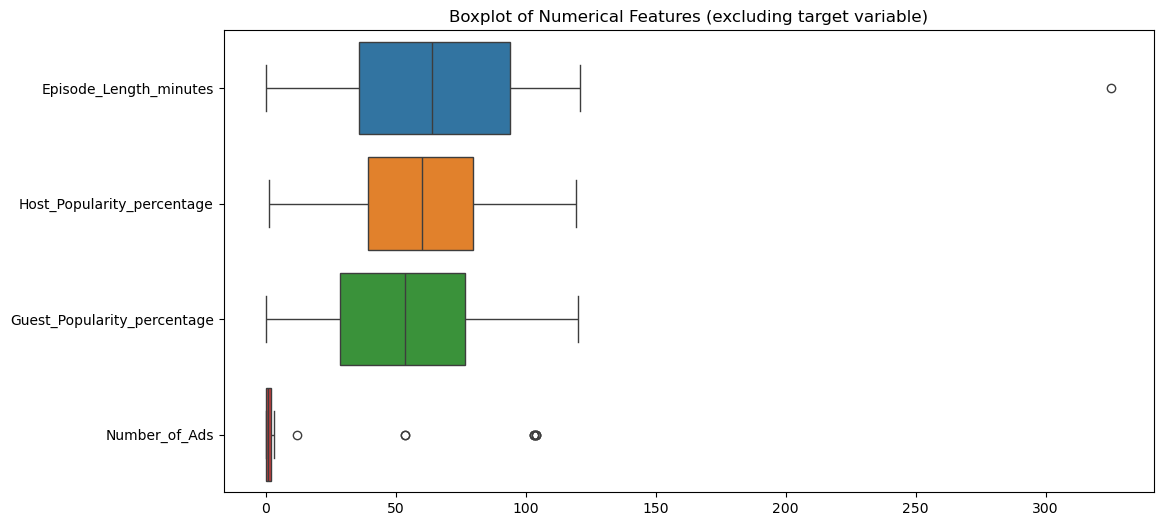

In [38]:
# Boxplot of all numerical columns, excluding the target variable. Checking for outliers through the formula Q1 - 1.5 * IQR and Q3 + 1.5 * IQR
plt.figure(figsize=(12, 6))
sns.boxplot(data=dfTrain.drop(columns=['Listening_Time_minutes']), orient='h')
plt.title('Boxplot of Numerical Features (excluding target variable)')
plt.show()


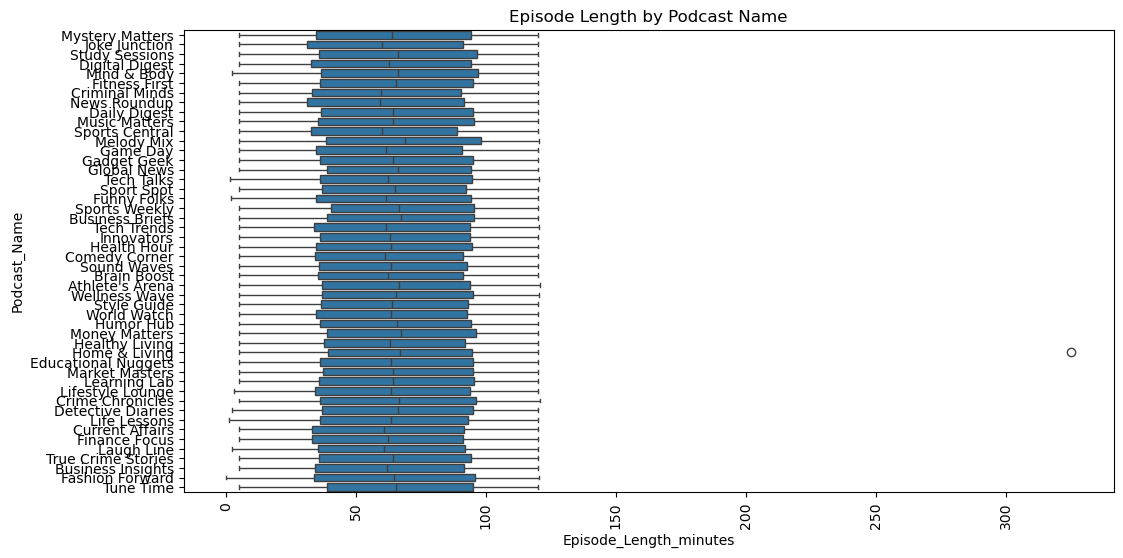

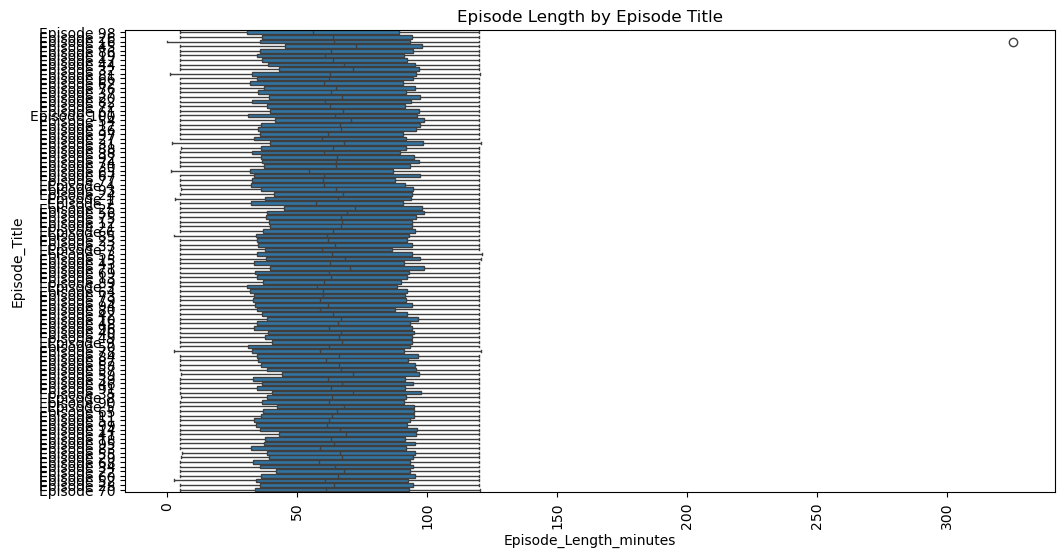

In [49]:
# Check Episode_length_minutes by Podcast_Name and also by Episode_Title
plt.figure(figsize=(12, 6))
sns.boxplot(data=dfTrain, x='Episode_Length_minutes', y='Podcast_Name')
plt.xticks(rotation=90)
plt.title('Episode Length by Podcast Name')
plt.show()
plt.figure(figsize=(12, 6))
sns.boxplot(data=dfTrain, x='Episode_Length_minutes', y='Episode_Title')
plt.xticks(rotation=90)
plt.title('Episode Length by Episode Title')
plt.show()

## Data Cleaning

In [39]:
# As 9 rows have more than 3 ads, we should take a look at them

ads_outliers = dfTrain[dfTrain['Number_of_Ads'] > 3]
ads_outliers

,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
211159,Wellness Wave,Episode 83,64.83,Health,48.46,Sunday,Evening,NaN,53.37,Positive,50.44892
283606,Health Hour,Episode 15,109.93,Health,67.81,Sunday,Morning,77.90,103.91,Neutral,103.89696
436577,Sports Central,Episode 64,115.25,Sports,28.58,Saturday,Afternoon,23.65,103.00,Neutral,103.12686
495919,Comedy Corner,Episode 79,64.83,Comedy,48.37,Saturday,Evening,NaN,53.42,Neutral,50.44892
537705,Sound Waves,Episode 64,112.27,Music,28.95,Saturday,Morning,10.15,103.75,Neutral,103.12686
567235,Detective Diaries,Episode 21,16.13,True Crime,49.11,Tuesday,Evening,43.17,12.00,Positive,6.49000
602553,Sound Waves,Episode 53,112.27,Music,28.19,Tuesday,Morning,23.15,103.25,Neutral,103.12686
672139,Sound Waves,Episode 35,115.74,Music,28.95,Tuesday,Afternoon,23.50,103.25,Neutral,103.12686
683147,Crime Chronicles,Episode 15,109.93,True Crime,59.66,Tuesday,Evening,77.91,103.88,Neutral,103.89696


Some of these numbers are not integers and do not make much sense. It is also interesting to note that they have the values 103 and 53, with the exception of one with 12. The podcast **Sound Waves** appeared 3 times in this list.

In [40]:
length_outliers = dfTrain[dfTrain['Episode_Length_minutes'] > 120]
length_outliers

,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
74270,Tech Trends,Episode 31,120.64,Technology,49.78,Saturday,Morning,50.54,1.0,Neutral,119.73000
87034,Tech Talks,Episode 31,120.32,Technology,78.39,Thursday,Morning,54.64,1.0,Neutral,119.66000
101637,Home & Living,Episode 16,325.24,Lifestyle,50.69,Tuesday,Afternoon,15.01,0.0,Positive,64.31981
168115,Wellness Wave,Episode 78,120.64,Health,49.78,Thursday,Morning,50.54,1.0,Neutral,119.73000
473895,Athlete's Arena,Episode 15,120.06,Sports,78.98,Saturday,Evening,56.64,1.0,Neutral,119.67000
516498,Fashion Forward,Episode 81,120.37,Lifestyle,79.40,Thursday,Afternoon,54.66,0.0,Neutral,119.44000
552181,Athlete's Arena,Episode 15,120.73,Sports,78.42,Friday,Evening,54.24,1.0,Neutral,119.67000
598106,Crime Chronicles,Episode 53,120.93,True Crime,48.73,Friday,Morning,72.96,2.0,Positive,70.90288
688205,Melody Mix,Episode 70,120.37,Music,76.45,Friday,Morning,54.74,1.0,Neutral,119.67000


As we could have expected from looking at the graph for the corresponding variable, there is an outlier with a length of **325.24** minutes that we should make a note of. Now, it is possible for a podcast to be 325 minutes long, but as it is the only one that is close to this value, we should make a note of it, as it is almost three times the length of the second longest podcast.

Finally, let's look whether any data point has been a `Listening_Time_minutes` higher than `Episode_Length_minutes`.

In [41]:
listening_higher_than_length = dfTrain[dfTrain['Listening_Time_minutes'] > dfTrain['Episode_Length_minutes']]
listening_higher_than_length

,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
113,Current Affairs,Episode 44,17.94000,News,96.55,Saturday,Morning,13.40,1.0,Neutral,17.94199
407,Sound Waves,Episode 56,11.26000,Music,44.26,Wednesday,Night,66.04,0.0,Positive,11.26579
864,Life Lessons,Episode 29,28.92000,Lifestyle,49.84,Wednesday,Morning,19.85,2.0,Neutral,28.92051
948,Educational Nuggets,Episode 59,96.10732,Education,85.95,Tuesday,Evening,90.83,2.0,Neutral,96.10741
1316,Market Masters,Episode 71,64.08000,Business,30.51,Sunday,Night,28.21,0.0,Positive,68.63865
...,...,...,...,...,...,...,...,...,...,...,...
749074,Gadget Geek,Episode 90,56.05000,Technology,54.09,Monday,Morning,68.02,0.0,Positive,60.11545
749554,Educational Nuggets,Episode 37,43.08000,Education,38.64,Wednesday,Afternoon,58.67,0.0,Negative,44.56000
749622,Lifestyle Lounge,Episode 8,52.69000,Lifestyle,90.80,Thursday,Evening,NaN,2.0,Positive,52.69952
749649,News Roundup,Episode 23,45.39000,News,96.09,Saturday,Morning,NaN,1.0,Neutral,46.61337


In [ ]:
# Because Episode_Length_minutes has many missing values, we should do some imputation
# Let's first do an analysis, We will check, in general, how much does listening time vary between each episode, using the first episode as a baseline.
# This is a first attempt to try and impute the missing values. We will not impute for now, just see the variation within the existing rows

# So let's see. We should group by the Episode_Title, then make a median and see how it varies from the first episode
episodeTitle_group = dfTrain.groupby('Episode_Title')['Episode_length'].median().reset_index()

In [ ]:
# Check if any row exists where Listening

In [110]:
# Let's now create a clean copy of the dataframe. We will create a function to clean the irregularities and outliers in the data sets, since they're only a few rows, we can drop them.
def clean_data(df, train=True):

    # First, let's do some imputation of the missing values. For the one in Ads, we can use the mode. For the rest, we can either choose the median or, in the case of Guest_Popularity_percentage, 0 if we are to assume that there was no guest in the episode.
    df['Number_of_Ads'] = df['Number_of_Ads'].fillna(df['Number_of_Ads'].mode()[0])
    # For now, we will use 0 for Guest_Popularity_percentage, but we can change it later if we want to.
    df['Guest_Popularity_percentage'] = df['Guest_Popularity_percentage'].fillna(0)

    # Regarding Host_Popularity_percentage and Guest_Popularity_percentage, if they are over 100, we will set them to 100. The idea is not to remove these rows, just change their values.
    df.loc[df['Host_Popularity_percentage'] > 100, 'Host_Popularity_percentage'] = 100
    df.loc[df['Guest_Popularity_percentage'] > 100, 'Guest_Popularity_percentage'] = 100
    
    # Drop rows with more than 3 ads
    df = df[df['Number_of_Ads'] <= 3]

    # Removing the podcast with over 130 minutes but keeping the NaN values

    df = df[(df['Episode_Length_minutes'] <= 130) | (df['Episode_Length_minutes'].isnull())]

    # Finally, disregarding NaN values, if the Listening_Time_minutes is greater than the Episode_Length_minutes, we will set it to the Episode_Length_minutes.
    if train:
        df.loc[(df['Listening_Time_minutes'] > df['Episode_Length_minutes']) & (df['Episode_Length_minutes'].notnull()), 'Listening_Time_minutes'] = df['Episode_Length_minutes']


    return df

# Clean the training and test dataframes
dfTrain_clean = clean_data(dfTrain.copy())
dfTest_clean = clean_data(dfTest.copy(), train=False)


In [111]:
dfTrain_clean.shape

(749990, 11)

## Enconding
As some of our features are categorical and represented as strings, we should encode them so the model can work better.

The features to be encoded are: Podcast_Name, Podcast_Name, Episode_Title, Genre, Publication_Day, Publication_Time and Episode_Sentiment, Genre, Publication_Day, Publication_Time and Episode_Sentiment

In [112]:

categorical_features = ['Podcast_Name', 'Genre', 'Publication_Time', 'Episode_Sentiment']

# Create function to encode categorical features, taking into account the Train and Test data. We have to be careful with the encoding, since we have to use the same encoding for both dataframes. All the variables are strings
def encode_categorical_features(dfTrain, dfTest, categorical_features):
    # Create a LabelEncoder object
    le = LabelEncoder()


    for feature in categorical_features:
        dfTrain[feature] = le.fit_transform(dfTrain[feature])
        dfTest[feature] = le.transform(dfTest[feature])
        mapping = dict(zip(le.classes_, le.transform(le.classes_)))
        print(f"Mapping for {feature}: {mapping}")
    
    return dfTrain, dfTest

# Encode the categorical features
dfTrain_clean, dfTest_clean = encode_categorical_features(dfTrain_clean, dfTest_clean, categorical_features)

# Episode_Title is treated a bit differently. A possible value is 'Episode 26', so we can just drop the 'Episode ' part and convert it to an integer. 
def clean_episode_title(df):
    df['Episode_Title'] = df['Episode_Title'].str.replace('Episode ', '').astype(int)
    return df

# Clean the Episode_Title column in both dataframes
dfTrain_clean = clean_episode_title(dfTrain_clean)
dfTest_clean = clean_episode_title(dfTest_clean)

# Finally, Publication_Day is a categorical variable, each value being a day of the week as string. We can convert it to a number, with Monday = 0 and Sunday = 6. We can use the .map() function to do this.
def clean_publication_day(df):
    days_mapping = {
        'Monday': 0,
        'Tuesday': 1,
        'Wednesday': 2,
        'Thursday': 3,
        'Friday': 4,
        'Saturday': 5,
        'Sunday': 6
    }
    df['Publication_Day'] = df['Publication_Day'].map(days_mapping)
    return df

# Clean the Publication_Day column in both dataframes
dfTrain_clean = clean_publication_day(dfTrain_clean)
dfTest_clean = clean_publication_day(dfTest_clean)

Mapping for Podcast_Name: {"Athlete's Arena": 0, 'Brain Boost': 1, 'Business Briefs': 2, 'Business Insights': 3, 'Comedy Corner': 4, 'Crime Chronicles': 5, 'Criminal Minds': 6, 'Current Affairs': 7, 'Daily Digest': 8, 'Detective Diaries': 9, 'Digital Digest': 10, 'Educational Nuggets': 11, 'Fashion Forward': 12, 'Finance Focus': 13, 'Fitness First': 14, 'Funny Folks': 15, 'Gadget Geek': 16, 'Game Day': 17, 'Global News': 18, 'Health Hour': 19, 'Healthy Living': 20, 'Home & Living': 21, 'Humor Hub': 22, 'Innovators': 23, 'Joke Junction': 24, 'Laugh Line': 25, 'Learning Lab': 26, 'Life Lessons': 27, 'Lifestyle Lounge': 28, 'Market Masters': 29, 'Melody Mix': 30, 'Mind & Body': 31, 'Money Matters': 32, 'Music Matters': 33, 'Mystery Matters': 34, 'News Roundup': 35, 'Sound Waves': 36, 'Sport Spot': 37, 'Sports Central': 38, 'Sports Weekly': 39, 'Study Sessions': 40, 'Style Guide': 41, 'Tech Talks': 42, 'Tech Trends': 43, 'True Crime Stories': 44, 'Tune Time': 45, 'Wellness Wave': 46, 'Worl

In [113]:
dfTrain_clean

,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,34,98,NaN,9,74.81,3,3,0.00,0.0,2,31.41998
1,24,26,119.80,1,66.95,5,0,75.95,2.0,0,88.01241
2,40,16,73.90,2,69.97,1,1,8.97,0.0,0,44.92531
3,10,45,67.17,8,57.22,0,2,78.70,2.0,2,46.27824
4,31,86,110.51,3,80.07,0,0,58.68,3.0,1,75.61031
...,...,...,...,...,...,...,...,...,...,...,...
749995,26,25,75.66,2,69.36,5,2,0.00,0.0,0,56.87058
749996,2,21,75.75,0,35.21,5,3,0.00,2.0,1,45.46242
749997,28,51,30.98,4,78.58,3,2,84.89,0.0,0,15.26000
749998,41,47,108.98,4,45.39,3,2,93.27,0.0,0,100.72939


In [114]:
dfTrain_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 749990 entries, 0 to 749999
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Podcast_Name                 749990 non-null  int32  
 1   Episode_Title                749990 non-null  int32  
 2   Episode_Length_minutes       662897 non-null  float64
 3   Genre                        749990 non-null  int32  
 4   Host_Popularity_percentage   749990 non-null  float64
 5   Publication_Day              749990 non-null  int64  
 6   Publication_Time             749990 non-null  int32  
 7   Guest_Popularity_percentage  749990 non-null  float64
 8   Number_of_Ads                749990 non-null  float64
 9   Episode_Sentiment            749990 non-null  int32  
 10  Listening_Time_minutes       749990 non-null  float64
dtypes: float64(5), int32(5), int64(1)
memory usage: 70.5 MB


In [115]:
def to_categorical(df):
    # Convert the columns to categorical
    df['Podcast_Name'] = df['Podcast_Name'].astype('category')
    df['Genre'] = df['Genre'].astype('category')
    df['Publication_Time'] = df['Publication_Time'].astype('category')
    df['Episode_Sentiment'] = df['Episode_Sentiment'].astype('category')
    
    return df

dfTrain_clean = to_categorical(dfTrain_clean)
dfTest_clean = to_categorical(dfTest_clean)

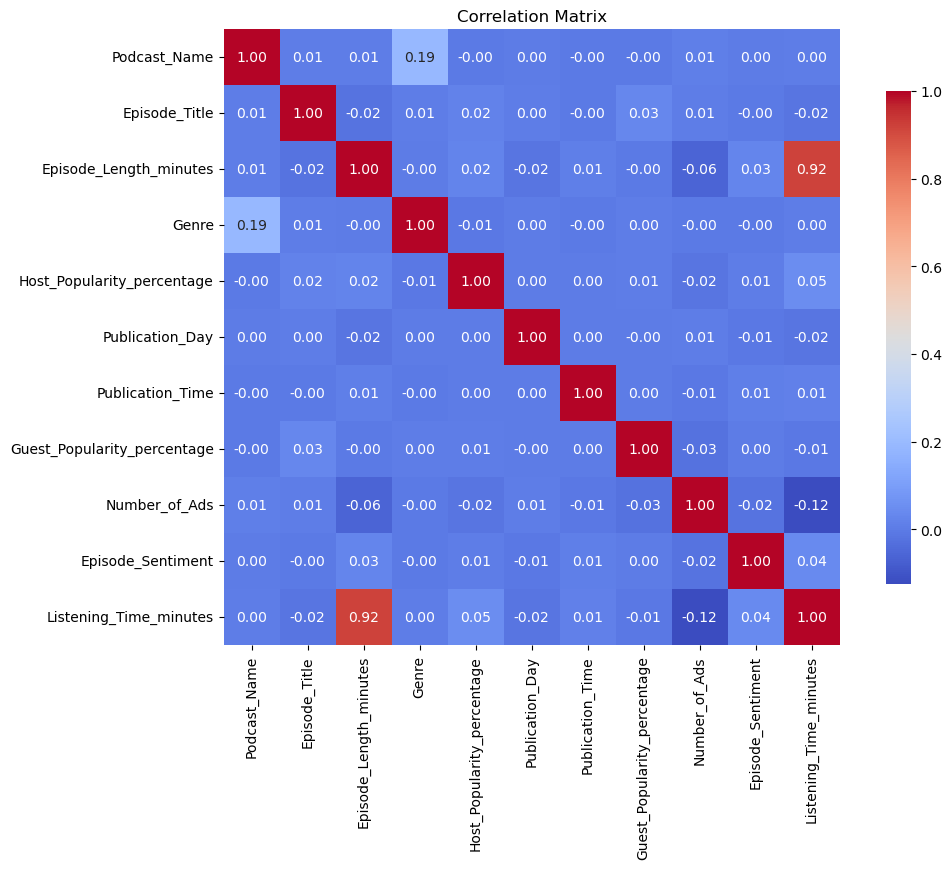

In [116]:
# Correlation matrix between the numerical features (excluding Genre, Podcast_Name, Publication_Day, Publication_Time, Episode_Sentiment, and Episode_Title)
plt.figure(figsize=(12, 8))
sns.heatmap(dfTrain_clean.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix')
plt.show()


From all of these, the only strong correlation to note is between `Episode_Length_minutes` and the target `Listening_Time_minutes`, which makes sense, since longer podcasts will be listened to for longer than a short normally could, assuming they're both engaging. `Ads` do have a bit of a higher correlation with the target, but still not very considerable. Most variables do not add anything, and can likely be disregarded for the model training.

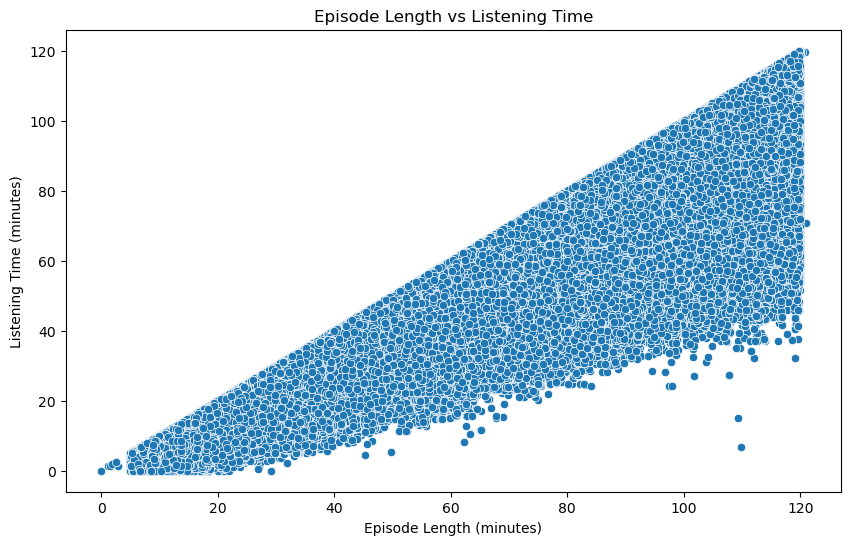

In [117]:
# Let's take a look at the strongest correlation, graphically
plt.figure(figsize=(10, 6))
sns.scatterplot(data=dfTrain_clean, x='Episode_Length_minutes', y='Listening_Time_minutes')
plt.title('Episode Length vs Listening Time')
plt.xlabel('Episode Length (minutes)')
plt.ylabel('Listening Time (minutes)')
plt.show()

As Chris Deotte explains in https://www.kaggle.com/competitions/playground-series-s5e4/discussion/573002, there are many correlations between variables, which imply the use of a non-linear model.

# Modelling

In [120]:
TARGET = 'Listening_Time_minutes'
N_SPLITS = 5 # Number of folds for K-Fold Cross-Validation [3][5]
RANDOM_STATE = 42 # For reproducibility

In [1]:
# Now, for the data to work with the model, the Categorical variables have to be converted. We have now the decision of using Label Encoding or One Hot Encoding.
# Publication Day, Publication Time, and Episode Sentiment have an order to them, so we can use Label Encoding. Podcast Name and Genre are nominal variables, so we can use One Hot Encoding.

def encode_categorical_features_le_oh(df, le_features, oh_features):
    # Create a LabelEncoder object
    le = LabelEncoder()

    # Apply Label Encoding to the specified features
    for feature in le_features:
        df[feature] = le.fit_transform(df[feature])
    
    # Apply One Hot Encoding to the specified features
    df = pd.get_dummies(df, columns=oh_features, drop_first=True)
    
    return df

# Define the features to be encoded
le_features = ['Publication_Day', 'Publication_Time', 'Episode_Sentiment']
oh_features = ['Podcast_Name', 'Genre']

# Encode the categorical features
dfTrain_cleanE = encode_categorical_features_le_oh(dfTrain_clean, le_features, oh_features)
dfTest_cleanE = encode_categorical_features_le_oh(dfTest_clean, le_features, oh_features)

NameError: name 'dfTrain_clean' is not defined

In [ ]:
X_train = dfTrain_clean.drop(columns=[TARGET])
y_train = dfTrain_clean[TARGET]
X_test = dfTest_clean.copy()

In [ ]:
import xgboost as xgb

class PodcastModeler:
    """
    Handles model training, evaluation using K-Fold CV, and prediction.
    """
    def __init__(self, model, n_splits, random_state):
        self.model = model
        self.n_splits = n_splits
        self.random_state = random_state
        self.kf = KFold(n_splits=self.n_splits, shuffle=True, random_state=self.random_state) # [3][5][7]
        self.oof_predictions = None
        self.test_predictions = None
        self.feature_importances = None
        self.cv_scores = []

    def train_evaluate_kfold(self, X, y):
        """Trains and evaluates the model using K-Fold Cross-Validation."""
        print(f"\n--- Training with {self.n_splits}-Fold Cross-Validation ---")
        self.oof_predictions = np.zeros(len(X))
        self.feature_importances = pd.DataFrame(index=X.columns)
        fold_models = [] # Store models from each fold if needed later

        for fold, (train_idx, val_idx) in enumerate(self.kf.split(X, y)):
            print(f"\nFold {fold+1}/{self.n_splits}")
            X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
            y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

            # Train the model for the current fold
            self.model.fit(X_train_fold, y_train_fold,
                           eval_set=[(X_val_fold, y_val_fold)],
                           eval_metric='rmse', # Root Mean Squared Error
                           callbacks=[lgb.early_stopping(100, verbose=False)]) # Early stopping

            # Store feature importances
            self.feature_importances[f'Fold_{fold+1}'] = self.model.feature_importances_

            # Make predictions on the validation set
            val_preds = self.model.predict(X_val_fold)
            self.oof_predictions[val_idx] = val_preds

            # Calculate and store RMSE for the fold
            fold_rmse = np.sqrt(mean_squared_error(y_val_fold, val_preds))
            self.cv_scores.append(fold_rmse)
            print(f"Fold {fold+1} RMSE: {fold_rmse:.4f}")
            fold_models.append(self.model) # Optional: keep trained fold models

        # Calculate overall OOF RMSE
        overall_oof_rmse = np.sqrt(mean_squared_error(y, self.oof_predictions))
        print(f"\nOverall OOF RMSE: {overall_oof_rmse:.4f}")
        print(f"Mean CV RMSE: {np.mean(self.cv_scores):.4f} (+/- {np.std(self.cv_scores):.4f})") # [7]

        # Calculate mean feature importances across folds
        self.feature_importances['mean'] = self.feature_importances.mean(axis=1)
        self.feature_importances = self.feature_importances.sort_values('mean', ascending=False)

        print("\nTop 10 Feature Importances (Mean across Folds):")
        print(self.feature_importances['mean'].head(10))

        # Plot feature importances
        plt.figure(figsize=(10, 8))
        sns.barplot(x='mean', y=self.feature_importances.index[:20], data=self.feature_importances.head(20)) # Show top 20
        plt.title('Mean Feature Importances across Folds')
        plt.tight_layout()
        plt.show()

        # It's generally recommended to retrain on the full dataset for final predictions
        # self.final_model = self.model # Or potentially retrain self.model on full X, y

    def train_final_model(self, X, y):
        """Trains the final model on the entire training dataset."""
        print("\n--- Training Final Model on Full Training Data ---")
        self.model.fit(X, y)
        print("Final model training complete.")
         # Store feature importances from the final model
        self.final_feature_importances = pd.DataFrame(
            {'feature': X.columns, 'importance': self.model.feature_importances_}
        ).sort_values('importance', ascending=False)

        print("\nFeature Importances (Final Model):")
        print(self.final_feature_importances.head(10))


    def predict(self, X_test):
        """Makes predictions on the test set using the final trained model."""
        print("\n--- Making Predictions on Test Data ---")
        if not hasattr(self, 'model') or not self.model.booster_:
             raise RuntimeError("Model has not been trained. Call train_final_model first.")
        self.test_predictions = self.model.predict(X_test)
        print("Test predictions generated.")
        return self.test_predictions


# ## 6. Pipeline Execution

# Initialize the model (LightGBM Regressor is often a good choice for tabular data)
# XGBoost parameters (example - tune these for better performance)
xgb_params = {
    'objective': 'reg:squarederror', # Objective function for regression
    'eval_metric': 'rmse',           # Evaluation metric
    'eta': 0.05,                     # Learning rate
    'max_depth': 7,                  # Maximum tree depth
    'subsample': 0.7,                # Fraction of samples used per tree
    'colsample_bytree': 0.7,         # Fraction of features used per tree
    'random_state': 42,
    'n_estimators': 1000,            # Number of boosting rounds (trees)
    'early_stopping_rounds': 50      # Stop if validation metric doesn't improve
    # Consider adding 'tree_method':'hist' for speed on large datasets
}

model = xgb.XGBRegressor(**xgb_params)

# Instantiate the Modeler
modeler = PodcastModeler(model=model, n_splits=N_SPLITS, random_state=RANDOM_STATE)

# Train and evaluate using K-Fold CV
# Note: We use the processed data from the Preprocessor class
modeler.train_evaluate_kfold(X_train_processed, y_train)

# Train the final model on the full training data
modeler.train_final_model(X_train_processed, y_train)

# Make predictions on the processed test data
test_preds = modeler.predict(X_test_processed)


# ## 7. Submission File Generation

print("\n--- Generating Submission File ---")
submission[TARGET] = test_preds

# Optional: Ensure predictions are non-negative if applicable
submission[TARGET] = submission[TARGET].apply(lambda x: max(0, x))

submission.to_csv('submission.csv', index=False)
print("Submission file 'submission.csv' created successfully.")
print(submission.head())

NameError: name 'xgb' is not defined